In [55]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = "olist_analysis.xlsx"   # or full path if needed

In [3]:
# Load all sheets
sheets = pd.read_excel(file_path, sheet_name=None)

In [4]:
# Check sheet names
print("Sheets found:", list(sheets.keys()))

Sheets found: ['revenue_by_state', 'payment_types', 'category_sale', 'Pivot Table', 'monthly_orders']


In [9]:
# Preview each sheet (first 3 rows)
for name, df in sheets.items():
    print(f"\n--- {name} ---")
    display(df.head(3))


--- revenue_by_state ---


,COLUMN 1,COLUMN 2
0,customer_state,total_revenue



--- payment_types ---


,PAYMENT_TYPE,TOTAL_TRANSACTIONS,TOTAL_AMOUNT
0,credit_card,4,297.21



--- category_sale ---


,COLUMN 1,COLUMN 2,COLUMN 3
0,product_category_name,total_sales,items_sold



--- Pivot Table ---


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,MONTH,NaN,NaN,NaN,NaN,NaN
2,NaN,2017-10,2017-11,2018-07,2018-08,(blank),Grand Total



--- monthly_orders ---


,MONTH,TOTAL_ORDERS
0,2017-10,1
1,2017-11,1
2,2018-07,1


In [21]:
df_state = sheets["revenue_by_state"]
df_payment = sheets["payment_types"]
df_category = sheets["category_sale"]
df_month = sheets["monthly_orders"]

print("Sheets loaded successfully!")


Sheets loaded successfully!


In [23]:
# Rename columns for consistency
df_state.columns = ["customer_state", "total_revenue"]
df_payment.columns = ["payment_type", "total_transactions", "total_amount"]
df_category.columns = ["product_category_name", "total_sales", "items_sold"]
df_month.columns = ["month", "total_orders"]

In [25]:
# Drop duplicates
df_state.drop_duplicates(inplace=True)
df_payment.drop_duplicates(inplace=True)
df_category.drop_duplicates(inplace=True)
df_month.drop_duplicates(inplace=True)


In [27]:
# Fill missing values
df_payment = df_payment.fillna({"payment_type": "unknown"})
df_category = df_category.fillna({"product_category_name": "unknown"})
df_state = df_state.fillna({"customer_state": "unknown"})
df_month = df_month.fillna({"total_orders": 0})

In [29]:
print("Cleaning complete!")

Cleaning complete!


In [31]:
le = LabelEncoder()

df_payment["payment_type_enc"] = le.fit_transform(df_payment["payment_type"])
df_category["category_enc"] = le.fit_transform(df_category["product_category_name"])
df_state["state_enc"] = le.fit_transform(df_state["customer_state"])

print("Encoding complete!")

Encoding complete!


In [37]:
to_scale = {
    "df_payment": ["total_amount"],
    "df_category": ["total_sales"],
    "df_state": ["total_revenue"]
}


In [39]:
# Helper to clean a single column to numeric
def clean_to_numeric(series, remove_chars=None):
    s = series.astype(str).copy()
    if remove_chars:
        for ch in remove_chars:
            s = s.str.replace(ch, "", regex=False)
    # strip whitespace
    s = s.str.strip()
    # coerce to numeric, invalid parsing becomes NaN
    return pd.to_numeric(s, errors="coerce")

In [41]:
# Apply scaling safely
scaler = MinMaxScaler()

for df_name, cols in to_scale.items():
    df = globals().get(df_name)
    if df is None:
        print(f"Warning: {df_name} not found in globals(), skipping.")
        continue

    for col in cols:
        if col not in df.columns:
            print(f"Warning: column '{col}' not in {df_name}, skipping.")
            continue

        # 1) Clean (remove common separators/currency)
        cleaned = clean_to_numeric(df[col], remove_chars=[",", "$", "€", "£"])
        n_nonnull = cleaned.notna().sum()
        n_total = len(cleaned)

        print(f"\n{df_name}.{col}: {n_nonnull}/{n_total} values convertible to numeric.")

        # 2) Decide how to handle NaNs: here we fill with 0 (optionally change to median)
        if cleaned.isna().any():
            # Options: fill with 0, or median:
            fill_method = "median"  # change to "zero" or "drop" if you prefer
            if fill_method == "zero":
                cleaned = cleaned.fillna(0)
            elif fill_method == "median":
                med = cleaned.median()
                cleaned = cleaned.fillna(med)
            elif fill_method == "drop":
                cleaned = cleaned
        if cleaned.nunique(dropna=True) <= 1:
            print(f"  -> Column '{col}' is constant after cleaning. Creating scaled column with zeros.")
            df[col + "_scaled"] = 0.0
            continue
            
        arr = cleaned.values.reshape(-1, 1)
        scaled = scaler.fit_transform(arr).reshape(-1)
        df[col + "_scaled"] = scaled

        # Replace original cleaned values if you want:
        df[col + "_clean"] = cleaned

    # write back to globals (not necessary since df is a reference, but explicit)
    globals()[df_name] = df

print("\nScaling finished. Scaled columns added with suffix '_scaled'.")


df_payment.total_amount: 1/1 values convertible to numeric.
  -> Column 'total_amount' is constant after cleaning. Creating scaled column with zeros.

df_category.total_sales: 0/1 values convertible to numeric.
  -> Column 'total_sales' is constant after cleaning. Creating scaled column with zeros.

df_state.total_revenue: 0/1 values convertible to numeric.
  -> Column 'total_revenue' is constant after cleaning. Creating scaled column with zeros.

Scaling finished. Scaled columns added with suffix '_scaled'.


In [43]:
# Run this to inspect the problematic column quickly
print(df_category.columns)        # or df_payment.columns / df_state.columns
print(df_category["total_sales"].head(10).to_list())
print(df_category["total_sales"].dtype)


Index(['product_category_name', 'total_sales', 'items_sold', 'category_enc',
       'total_sales_scaled'],
      dtype='object')
['total_sales']
object


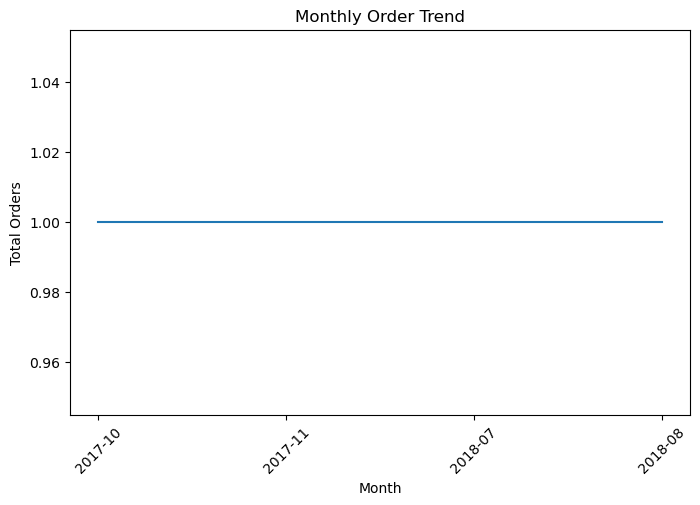

In [45]:
# ----- Monthly Trend Line Chart -----
plt.figure(figsize=(8,5))
plt.plot(df_month["month"], df_month["total_orders"])
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.show()

In [51]:
# Ensure numeric
df_category["total_sales"] = pd.to_numeric(df_category["total_sales"], errors="coerce").fillna(0)

print(df_category.dtypes)

product_category_name     object
total_sales              float64
items_sold                object
category_enc               int32
total_sales_scaled       float64
dtype: object


<Figure size 800x500 with 0 Axes>

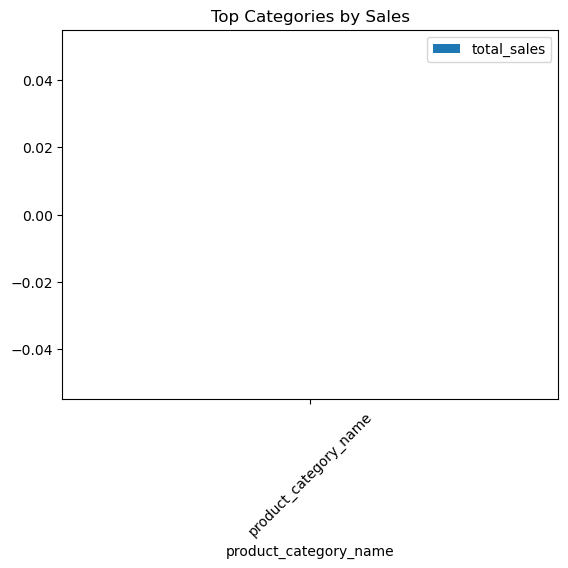

In [57]:
# Plot only if DataFrame has rows
if len(df_category) == 0:
    print("df_category is empty — cannot plot bar chart.")
else:
    plt.figure(figsize=(8,5))
    (df_category
        .sort_values("total_sales", ascending=False)
        .head(10)
        .plot(x="product_category_name", y="total_sales", kind="bar")
    )
    plt.title("Top Categories by Sales")
    plt.xticks(rotation=45)
    plt.show()

Numeric columns found for heatmap: ['total_sales', 'category_enc', 'total_sales_scaled']


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


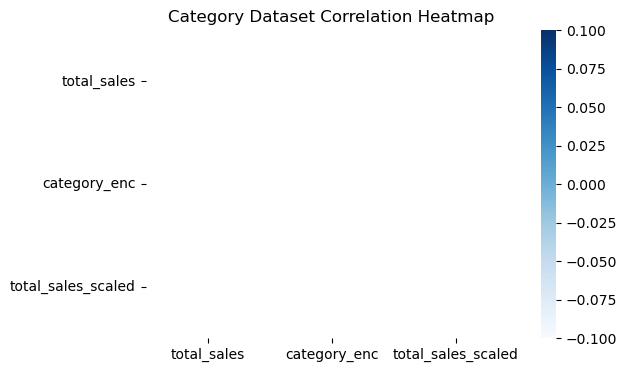

In [59]:
numeric_cols = df_category.select_dtypes(include=["number"])

print("Numeric columns found for heatmap:", numeric_cols.columns.tolist())  # debug

if len(numeric_cols.columns) < 2:
    print("Not enough numeric columns for correlation heatmap.")
else:
    plt.figure(figsize=(6,4))
    sns.heatmap(numeric_cols.corr(), annot=True, cmap="Blues")
    plt.title("Category Dataset Correlation Heatmap")
    plt.show()

In [61]:
df_category.head()


,product_category_name,total_sales,items_sold,category_enc,total_sales_scaled
0,product_category_name,0.0,items_sold,0,0.0


In [63]:
df_category.dtypes

product_category_name     object
total_sales              float64
items_sold                object
category_enc               int32
total_sales_scaled       float64
dtype: object